In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Variational Principle

### Plot of analytical $\psi_0(x), \psi_1(x),$ and $\psi_2(x)$ solutions

In [ ]:
x_space = np.linspace(-5, 5, 500) # grid/line of x values in an array
psi0 = np.pi**(-1/4) * np.exp(-x_space**2/2) # y-values for analytical solution of n = 0 wavefunction
psi1 = # fill this out
psi2 = # fill this out

E0 = 0.5 # zero point energy
E1 = 1.5
E2 = 2.5


fig, ax = plt.subplots() # Plot energy and functions

# plot the potential
x_space_potential = np.linspace(-2.5, 2.5, 500) # 1D grid for potential
potential = 0.5 * x_space_potential**2 # evaluate y values for 1D grid
ax.plot(x_space_potential, potential, 'k--', label='U(x)') # plot potential

# plot horizontle line for eigen energies 
ax.hlines(E0, -5, 5, colors='gray', linestyles=':')
ax.hlines(E1, -5, 5, colors='gray', linestyles=':')
ax.hlines(E2, -5, 5, colors='gray', linestyles=':')

# plot the exact wavefunctions
ax.plot(x_space, E0 + psi0, label=r'$\psi_0 (x)$')
ax.plot(x_space, E1 + psi1, label=r'$\psi_1 (x)$')
ax.plot(x_space, E2 + psi2, label=r'$\psi_2 (x)$')

ax.set_xlabel('x')
ax.set_ylabel('U(x)')
ax.legend()

plt.savefig('Figures/HO_analytical.png')

### Matrix Element Evaluations (Integrals)

Given the basis functions:

$$
\phi_{\mu} (x) = \exp\left( - \alpha (x-x_A)^2\right) \\
\phi_{\nu} (x) = \exp\left( - \alpha (x-x_B)^2\right) 
$$

Note the following integrals:

$$
S_{\mu\nu} = \langle\phi_{\mu}| \phi_{\nu}\rangle = \int dx \exp\left( - \alpha (x-x_A)^2\right)
\exp \left( - \alpha (x-x_B)^2 \right)
$$

$$H_{\mu\nu} = \langle\phi_{\mu}| H |\phi_{\nu}\rangle = \int dx \exp\left( - \alpha (x-x_A)^2\right) 
\left(-\frac{d^2}{dx^2} + \frac{1}{2} x^2\right) 
\exp \left( - \alpha (x-x_B)^2 \right)$$

The analytical solutions to these integrals are:

$$
S_{\mu\nu} = \sqrt{\dfrac{\pi}{2\alpha}}
\exp \left( - \dfrac{\alpha}{2} (x_A-x_B)^2 \right)
$$

$$
H_{\mu\nu} = \dfrac{1}{2}S_{\mu\nu}
\left[
\alpha - \alpha^2(x_A-x_B)^2 + \dfrac{1}{4}(\dfrac{1}{2} + (x_A+x_B)^2)
\right]
$$

In [ ]:
def S_uv_eval(xA, xB, alpha):
    return  # fill this out    

def H_uv_eval(xA, xB, alpha):
    return # fill this out

### Main Solver

In [ ]:
def phi_A(x_space, xA, alpha=2): # compute y-values of gaussian basis function
    return np.exp(-alpha*(x_space - xA) ** 2.) # returns an array of y-values with same dimension as x_space (numpy broadcasting)

def build_wavefunction(x_space, gaussian_centers, eigvec, state_index, alpha): # build variationally optimized wavefunction from coefficients
    psi = np.zeros_like(x_space) # create array of zeros with same dimensions as x_space
    
    for i, xA in enumerate(gaussian_centers):
        psi += # fill this out
    
    return psi

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def phi_A(x_space, xA, alpha=2): # compute y-values of gaussian basis function
    return np.exp(-alpha*(x_space - xA) ** 2.) # returns an array of y-values with same dimension as x_space (numpy broadcasting)

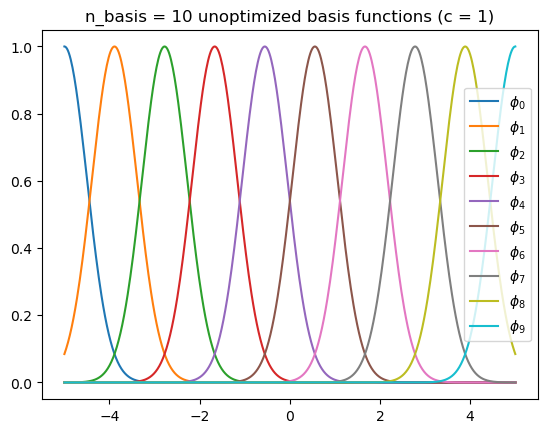

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def phi_A(x_space, xA, alpha=2): # compute y-values of gaussian basis function
    return np.exp(-alpha*(x_space - xA) ** 2.) # returns an array of y-values with same dimension as x_space (numpy broadcasting)

alpha = 2 
n_basis = 10

x_space = np.linspace(-5, 5, 500) 
gaussian_centers = np.linspace(-5, 5, n_basis)
psis = [phi_A(x_space, xA, alpha) for xA in gaussian_centers]

fig, ax = plt.subplots() # plot of gaussian basis funcitons with all coefficients c = 1 (unoptimized basis)
for index, psi in enumerate(psis):
    ax.plot(x_space, psi, label=rf'$\phi_{index}$')
ax.set_title('n_basis = 10 unoptimized basis functions (c = 1)')
ax.legend()


In [ ]:
alpha = 2
n_basis = 5

gaussian_centers = np.linspace(-5, 5, n_basis) # creates n_bases equally spaced between -5 to 5

S = np.zeros((n_basis, n_basis))
H = np.zeros((n_basis, n_basis))

for u, xA in enumerate(gaussian_centers):
    for v, xB in enumerate(gaussian_centers):
        S[u, v] = S_uv_eval(xA, xB, alpha)
        H[u, v] = H_uv_eval(xA, xB, alpha)

s, U =  # Diagonalize S (np.linalg.eigh automatically sorts the eigenvals and eigenvecs from smallest to largest)
s_inv_sqrt =  # build s^{-1/2]} (onsider using np.diag)
X = # build orthogonalizer X = S^{-1/2}

H_prime =  # transform Hamiltonian into orthogonal basis
E, C_prime =  # solve TISE
C = # transform eigenvector back to original basis

print(E)
print(C)

x_space = np.linspace(-5, 5, 500) 
psi0_var = build_wavefunction(x_space, gaussian_centers, C, 0, alpha) # build linear combination of basis functions with optimized coefficients 
psi1_var = build_wavefunction(x_space, gaussian_centers, C, 1, alpha)
psi2_var = build_wavefunction(x_space, gaussian_centers, C, 2, alpha)


x_space_potential = np.linspace(-2.5, 2.5, 500)
potential = 0.5 * x_space_potential**2 

x_space = np.linspace(-5, 5, 500) 
psi0 = np.pi**(-1/4) * np.exp(-x_space**2/2)
psi1 = np.pi**(-1/4) * (2**0.5) * x_space * np.exp(-x_space**2/2)
psi2 = np.pi**(-1/4) * (2 ** -0.5) * (2 * x_space**2 - 1) * np.exp(-x_space**2/2)

E0 = 0.5 
E1 = 1.5
E2 = 2.5



fig, ax = plt.subplots() # Build Plot

# plot the potential
ax.plot(x_space_potential, potential, 'k--', label='U(x)')

# plot horizontle line for exact energies 
ax.hlines(E0, -5, 5, colors='gray', linestyles=':')
ax.hlines(E1, -5, 5, colors='gray', linestyles=':')
ax.hlines(E2, -5, 5, colors='gray', linestyles=':')

# plot the exact wavefunctions
ax.plot(x_space, E0 + psi0, label=r'$\psi_0 (x)$ analytical')
ax.plot(x_space, E1 + psi1, label=r'$\psi_1 (x)$ analytical')
ax.plot(x_space, E2 + psi2, label=r'$\psi_2 (x)$ analytical')

# plot horizontle line for variationally minimized energies 
ax.hlines(E[0], -5, 5, colors='gray', linestyles='-.', label=f'$E_0$ var = {E[0]:.5f}')
ax.hlines(E[1], -5, 5, colors='gray', linestyles='-.', label=f'$E_1$ var = {E[1]:.5f}')
ax.hlines(E[2], -5, 5, colors='gray', linestyles='-.', label=f'$E_2$ var = {E[2]:.5f}')

# plot the approximate wavefunctions
ax.plot(x_space, E[0] - psi0_var, label=r'$\psi_0 (x)$ variational')
ax.plot(x_space, E[1] + psi1_var, label=r'$\psi_1 (x)$ variational')
ax.plot(x_space, E[2] - psi2_var, label=r'$\psi_2 (x)$ variational')


ax.set_xlabel('x')
ax.set_ylabel('U(x)')
ax.set_title('HO approximation with n_basis = 5')
ax.legend(bbox_to_anchor=(1, 1))

plt.savefig('Figures/HO_variational_5.png')